Code cells adapted from 1d_energy_comparison.ipynb in the pvqz_basis_set_comparison folder

In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

In [5]:
file_names = ['cv_1d_sorted.txt','f12_1d.txt'] #f12 means no core valence corrections only f12
energy_names = ['cv', 'f12']
hartree_to_cm = 219474.6313705

def load_coords_energy(file_name):
    """loads in unsorted basis set energy files"""
    #sort file by coordinates first
    energy_file = np.loadtxt(file_name)
    sort_idx = np.argsort(energy_file[:,7])
    energy_file = energy_file[sort_idx]
    
    #convert hartree to wavenumber, set minimum
    energy_file[:,6] = energy_file[:,6]*hartree_to_cm
    energy_file[:,6] = energy_file[:,6] - min(energy_file[:,6])
    
    #separate coords and energy
    return (energy_file[:,:6], energy_file[:,6])


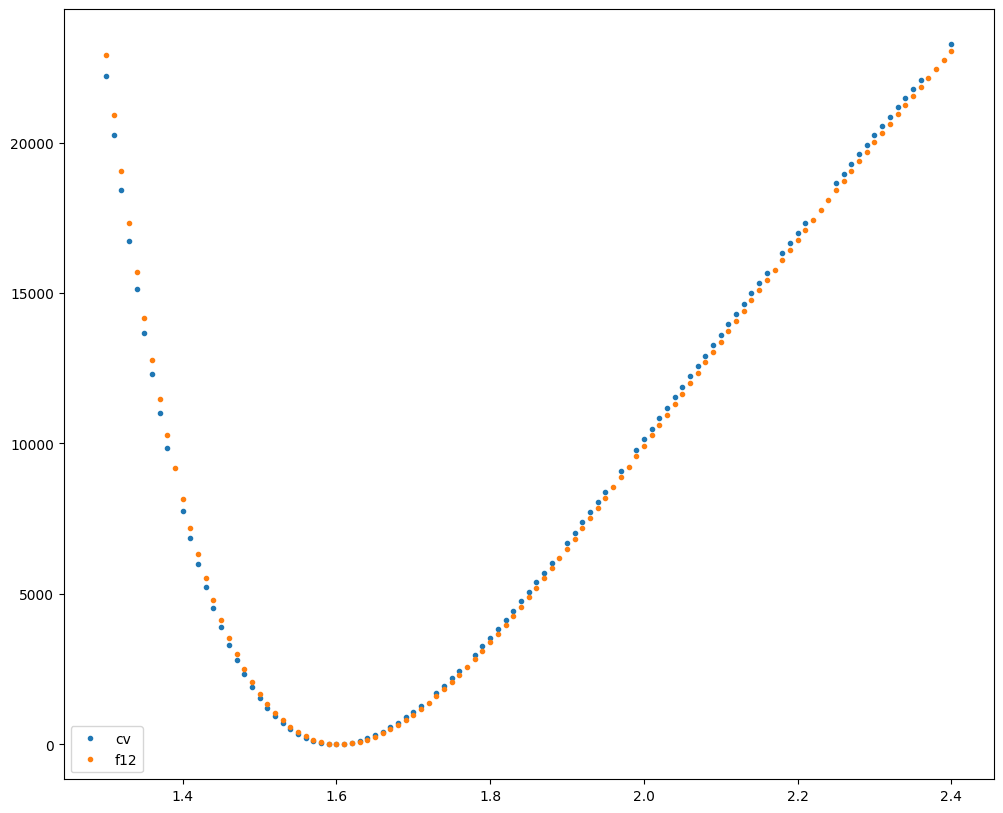

In [6]:
#initialize plot, different plot features
fig, ax = plt.subplots(figsize=(12,10))

for i in range(2):
    coords, energy = load_coords_energy(file_names[i])
    ax.plot(coords[:,1], energy, '.', label=f'{energy_names[i]}')
ax.legend(loc='best')